# Assignment 2- kNN
Katherine DeForrest

## Q1

1. Regression tries to predict a numeric value based on the given features, while classification tries to predict a categorical variable with the other features given. 
2. A confusion table is used for classification algorithms. It compares the predicted values from a model with the actual values. This allows us to see for what categories a model is able to predict accurately, and for what categories it struggles to classify correctly. It can also show, overall, how a model is performing. 
3. Accuracy is the overall proportion of cases that were predicted correctly and is used for classfication. It may not always be sufficient to evaluate a classifier's predictive performance as it provides an overall estimate of model accuracy, rather than information on the correct and incorrect predictions for each category. Therefore, it may miss reporting on where specifically the model fails, which may be the areas that one is trying to most accurately predict. 
4. The root mean squared error measures the accuracy and error of the regression. It is the square root of the sum of the residuals squared divided by the sample size. 
5. Overfitting is training the model to be highly sensitive to the training data, so it captures noise and details, and may not be generalizable to the testing data. This can occur when the k-value is too small. In contrast, underfitting is when the k-value may be too large and may oversimplify the data, so the model does not pick up on patterns and cannot make accurate predictions. 
6. Splitting the training and testing sets can ensure that the model can be used on another set of data besides the one that it was trained on. If you train a model just on one set of data, it can lead to overfitting, and it is impossible to see how the model generalizes to other data because you do not want to evaluate performance on the data on which the model was trainied. When choosing k, you want to choose the one that would be the most generalizable model. This means that, for each k, you would see how the accuracy changes, and choose the one in which the error is minimized without overfitting or underfitting the data. One way to see this is at the elbow point of a line graph of all possible ks, which would show where error is minimized without making the model too complex too simple. 
7. By using a class label as a prediction, it can allow for easier interpretablity, as each data point is put into a single category. This makes it easier to make decisions about the data, and it is easier for others to read. However, in using hard classifications, information can be lost because there is a hard cutoff for each category. So, if one data point may be on the edge of one category or another, it can only be classified as one and this information is lost. In contrast, using a probability distribution over class labels can add this information in the confidence in a prediction, allowing for more informed decisions about the data. However, it still cannot be a completely accurate model, so the confidence still cannot ensure that a prediction is correct, and it can make it more difficult to read and interpret an output, especially for other readers, when having strict labels would be easier to use. 

## Q3

In [112]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
#1. 

df = pd.read_csv('/workspace/scratchpad/data/USA_cars_datasets.csv')
df = df[["price", "year", "mileage"]]
print(df.head())
print("Dimensions:", df.ndim)
print(df.isnull().sum())
df.describe()

   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654
Dimensions: 2
price      0
year       0
mileage    0
dtype: int64


,price,year,mileage
count,2499.000000,2499.000000,2.499000e+03
mean,18767.671469,2016.714286,5.229869e+04
std,12116.094936,3.442656,5.970552e+04
min,0.000000,1973.000000,0.000000e+00
25%,10200.000000,2016.000000,2.146650e+04
50%,16900.000000,2018.000000,3.536500e+04
75%,25555.500000,2019.000000,6.347250e+04
max,84900.000000,2020.000000,1.017936e+06


There are 2 dimensions and no NA's to handle. 

In [114]:
#2. 

def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

X = df[["year", "mileage"]]
y = df["price"]

X = X.apply(minmax)

X.head()


,year,mileage
0,0.744681,0.269287
1,0.808511,0.187194
2,0.957447,0.038892
3,0.872340,0.063016
4,0.957447,0.006537


In [115]:
#3. 

from sklearn.model_selection import train_test_split

u_train, u_test, y_train, y_test = train_test_split(X,y, # Feature and target variables
                                                    test_size=.2, # Split the sample 80 train/ 20 test
                                                    random_state=100)


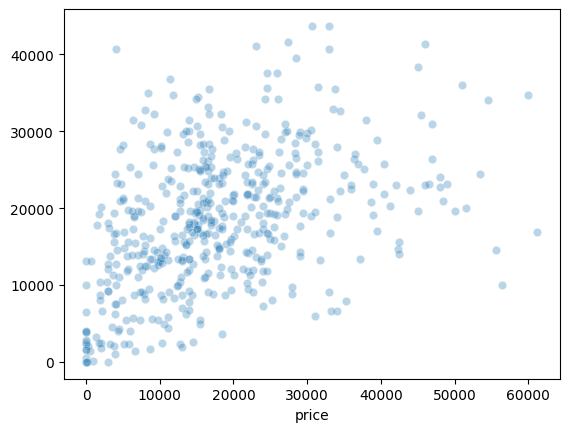

MSE for k=3: 126446573.21822223


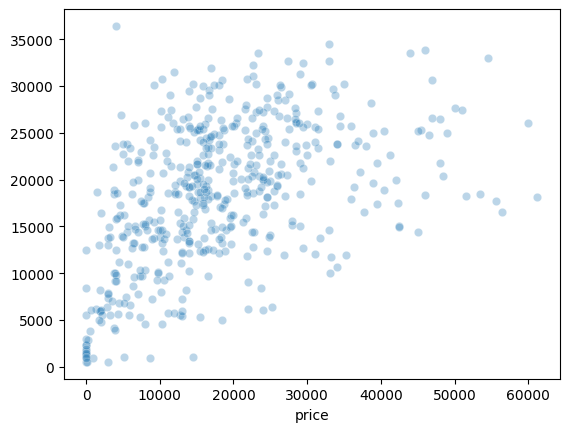

MSE for k=10: 110802185.58682


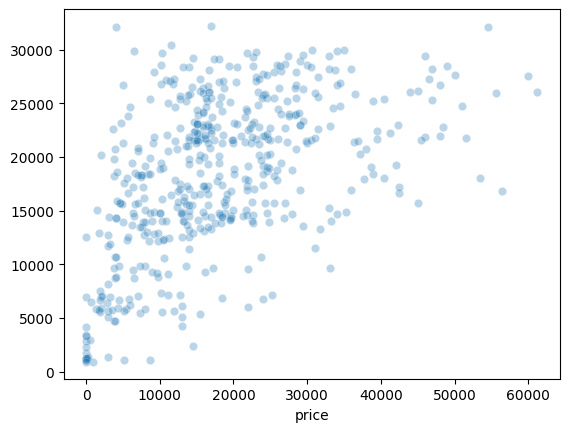

MSE for k=25: 103170457.84860799


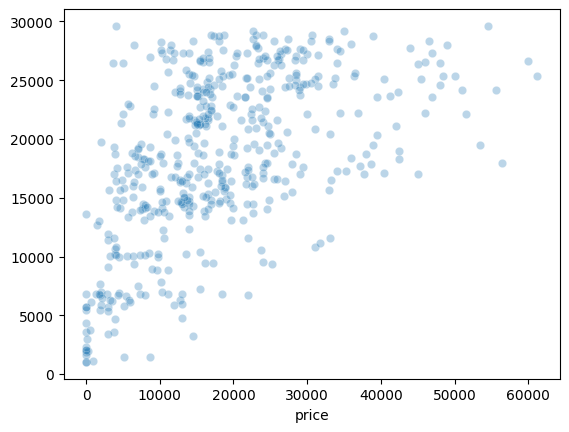

MSE for k=50: 99695443.96419601


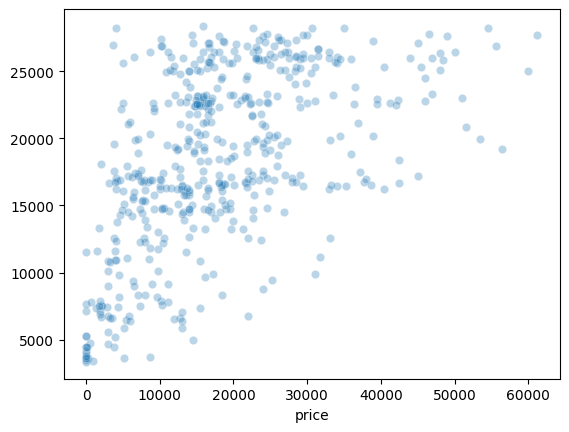

MSE for k=100: 98271058.9609206


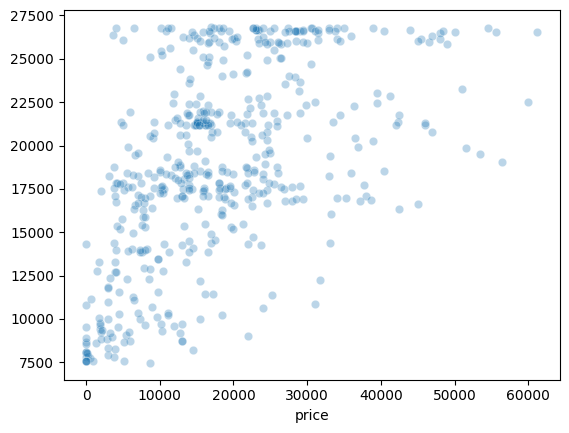

MSE for k=300: 100477298.914212


In [116]:
#4. 

from sklearn.neighbors import KNeighborsRegressor

ks = [3,10, 25, 50, 100, 300]
accuracy = []

def mse(y,y_hat):
    mse = np.sum(((y_test-y_hat)**2)/len(y_test))
    return mse

for k in ks:
    model = KNeighborsRegressor(n_neighbors=k)
    model = model.fit(u_train,y_train)
    y_hat = model.predict(u_test)
    accuracy.append(mse(y_test,y_hat))
    sns.scatterplot(x=y_test, y=y_hat, alpha =.3)
    plt.show()
    print(f"MSE for k={k}: {mse(y_test,y_hat)}")


As k increases, the MSE first decreases, and then increases again. Additionally, as k increases, the data points become more and more clustered together on the scatterplot in bands, indicating that the model may become too generalized with low variance and high bias and may be underfitting the data, while when k is small it may be overfitting the data with high variance and low bias. 

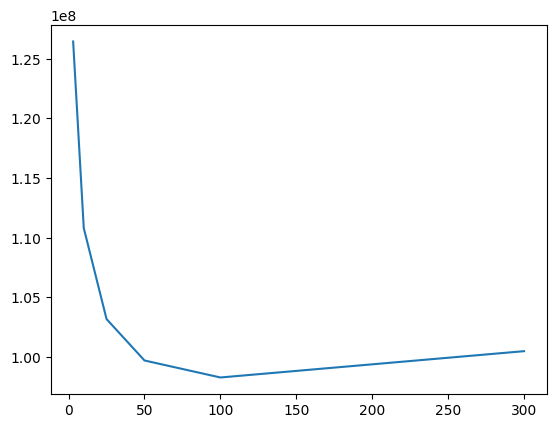

In [117]:
#5. 

sns.lineplot(x=ks, y=accuracy) 
plt.show()

The optimal k for this data is 100, or the elbow point of the graph. This is where the MSE is minimized and prevents a k that is overfitting and too small and one that is too large and underfitting. This will allow for a model that is able to most accurately predict the overall patterns of the data. 

6. 

As k increases, the scatterplots illustrate the bias-variance tradeoff. When k is small, there is high variance and low bias in the model, as the data is more closely matching individual points and the training data, which could therefore result in overfitting of the training data. As k becomes larger, it averages more data points to make predictions, which allows variance to decrease and the bias to increase. This allowed the points to cluster together more in bands. However, this can result in underfitting as the model generalizes the data with a large k. 

## Q2

In [118]:
#1. 

df = pd.read_csv('/workspace/scratchpad/data/land_mines.csv')
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [119]:
df.describe()

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


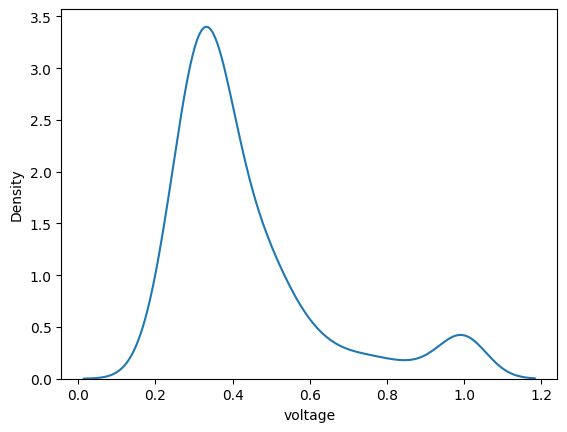

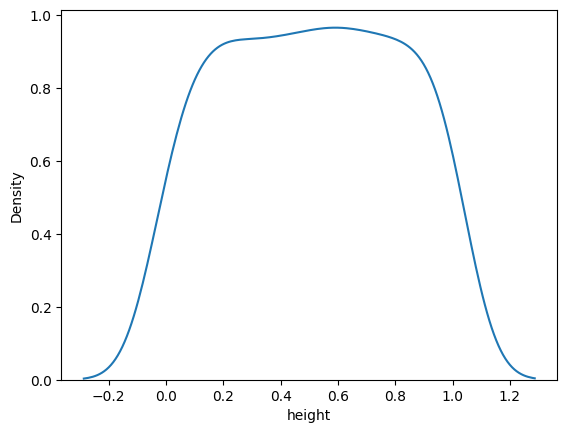

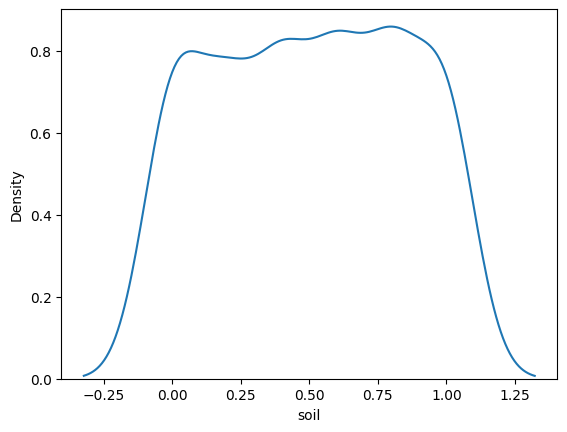

In [120]:
sns.kdeplot(x=df["voltage"])
plt.show()

sns.kdeplot(x=df["height"])
plt.show()

sns.kdeplot(x=df["soil"])
plt.show()

In [121]:
df.value_counts("soil")

soil
0.0    59
0.8    58
0.6    57
1.0    57
0.4    56
0.2    51
Name: count, dtype: int64

In [122]:
df.value_counts("height")

height
0.181818    30
0.545455    30
0.636364    30
0.363636    29
0.454545    29
0.727273    29
0.818182    29
0.272727    28
0.909091    28
0.090909    27
1.000000    27
0.000000    22
Name: count, dtype: int64

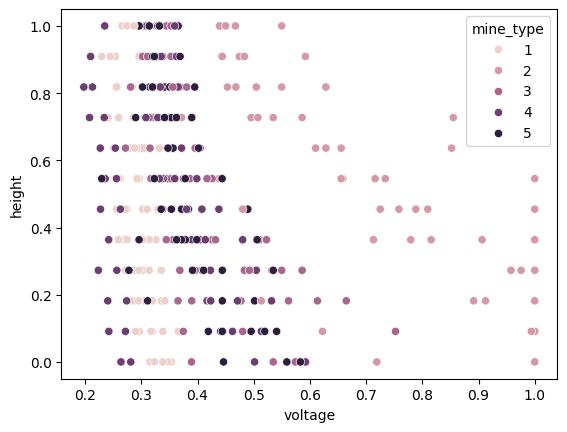

In [123]:
sns.scatterplot(x=df["voltage"], y=df["height"], hue=df["mine_type"])
plt.show()

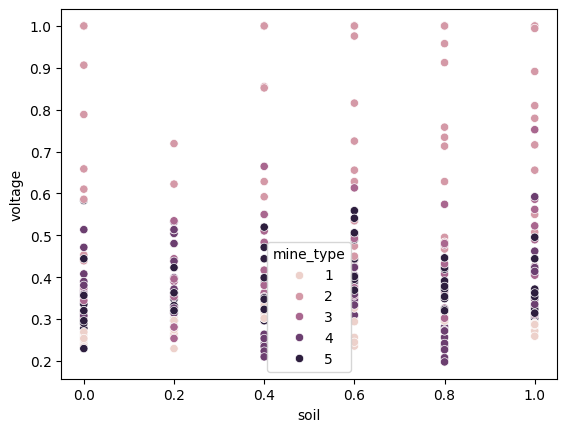

In [124]:
sns.scatterplot(x=df["soil"], y=df["voltage"], hue=df["mine_type"])
plt.show()

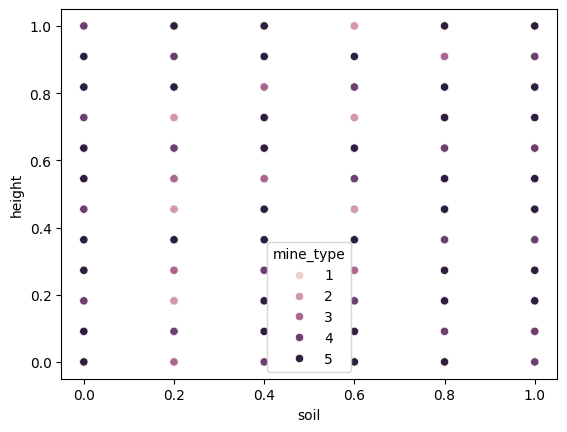

In [125]:
sns.scatterplot(x=df["soil"], y=df["height"], hue=df["mine_type"])
plt.show()

#both of these variables are evenly districuted, so this scatterplot does not show much

<Axes: xlabel='mine_type', ylabel='voltage'>

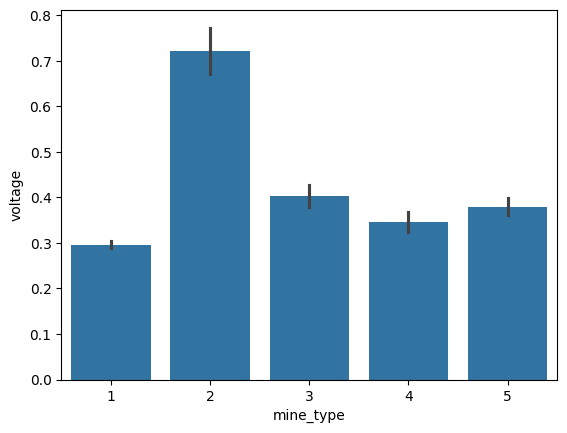

In [126]:
sns.barplot(x=df["mine_type"], y=df["voltage"])

<Axes: xlabel='mine_type', ylabel='height'>

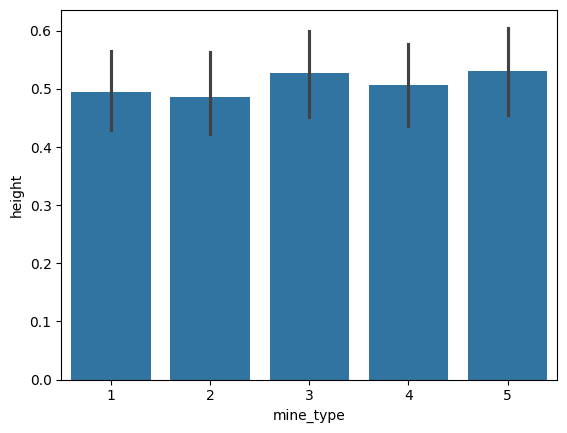

In [127]:
sns.barplot(x=df["mine_type"], y=df["height"])

<Axes: xlabel='mine_type', ylabel='soil'>

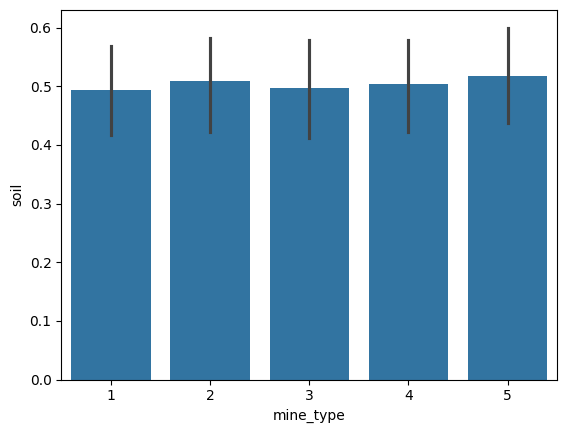

In [128]:
sns.barplot(x=df["mine_type"], y=df["soil"])

<Axes: xlabel='mine_type', ylabel='count'>

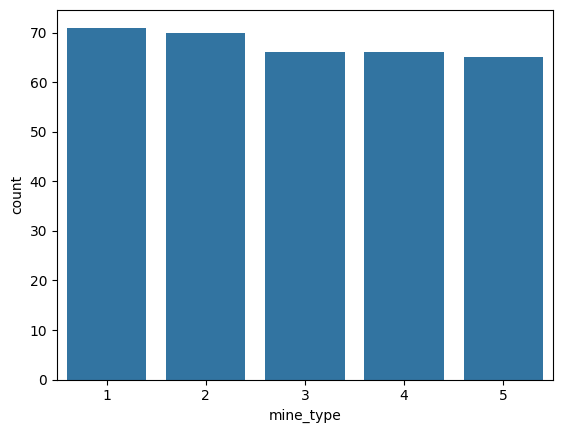

In [129]:
sns.countplot(x=df["mine_type"])

The properties height and soil, although they may seem continuous, are actually categorical as they are grouped in levels ranging from 0 to 1, and there are limited values that they can take. Both of these variables are also mostly uniformly distributed, with roughly even amounts of mines in each category. The voltage variable is slightly right-skewed with some outliers. All three of the features span from 0 to 1, allowing them to be compared on the same scale without being standardized. From the scatterplot, the height and voltage variables have a negative association, that also seems to correlate with mine type. It is difficult to read the other scatterplots as the height and soil variables are both categorical numeric features and are evenly distributed. Mine type also appears to be evenly distributed. When compared across the variables, mine type stays evenly distributed, except voltage, where type 2 mines are associated with with a higher voltage. 

In [130]:
#2. 

from sklearn.model_selection import train_test_split

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

u_train, u_test, y_train, y_test = train_test_split(X,y, # Feature and target variables
                                                    test_size=.5, # Split the sample 50 train/ 50 test
                                                    random_state=100)




In [131]:
#3. 

from sklearn.neighbors import KNeighborsClassifier

k = 13
# Create a fitted model instance:
model = KNeighborsClassifier(n_neighbors = k) # Create a model instance
model = model.fit(u_train,y_train) # Fit the model, training set
y_hat = model.predict(u_test) # Predictions, test set
model.score(u_test,y_test) # Test accuracy

0.39644970414201186

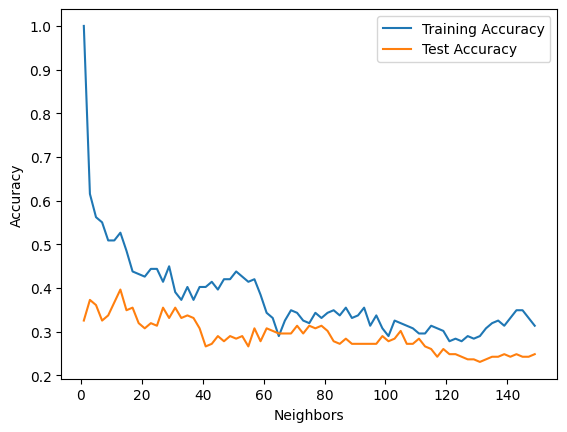

In [132]:
k_grid = np.array([(2*k+1) for k in range(75)])
accuracy = []

test_accuracies = []
train_accuracies = []
for k in k_grid: 
    model = KNeighborsClassifier(n_neighbors = k) 
    model = model.fit(u_train,y_train) 
    y_hat = model.predict(u_test) 
    test_acc = model.score(u_test,y_test) 
    train_acc = model.score(u_train,y_train) 
    test_accuracies.append(test_acc) 
    train_accuracies.append(train_acc) 
    
sns.lineplot(x=k_grid,y=train_accuracies,label='Training Accuracy').set(xlabel='Neighbors',ylabel='Accuracy')
sns.lineplot(x=k_grid,y=test_accuracies,label='Test Accuracy')
plt.show()

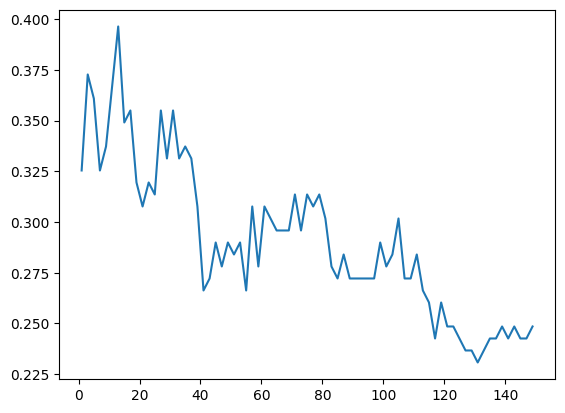

In [82]:
ks = sns.lineplot(x=k_grid, y=test_accuracies)


In [134]:
is_optimal = test_accuracies == np.max(test_accuracies)
optimal_indices = np.where( is_optimal ) 
k_optimal = k_grid[ optimal_indices ]
print(f"Optimal k: {k_optimal}")

# finding the optimal k value where the test accuracy is the highest


Optimal k: [13]


I selected my k by looking at where the test accuracy was the highest from testing a range of ks from 0 to 150, or k=13. I then chose this to be my k to maximize the accuracy of the model. 

In [111]:
#4. 

print( pd.crosstab(y_test, y_hat))

col_0       1   2   3  4   5
mine_type                   
1          26   0  10  0   2
2           0  21   7  2   5
3           3   3   8  0  19
4          17   0   7  4   7
5           7   0  13  0   8


As seen above, the model score is .39, so roughly 39% of the mines were categorized correctly. The model is able to more accurately predict the first and second type of mines, and is most accurately able to predict the second type of mine. For the fourth type of mine, the model tends to predict it mostly as the first mine type. Additionally, the model often confuses the third and the fifth mine types. In the confusion matrix, it predicts 19 type three mines as type five mines, and 13 type five mines as type three mines. Therefore, the model is not entirely accurate, and while it can predict the first two types of mines fairly well, it struggles to predict the other types and often confuses the third and fifth types of mines, as well as often categorizes the fourth type as the first type. 

5. 

Given the errors that this model tends to make, particularly that it often confuses the third and fifth types of mines, I would advise someone to not use it for these predictions, which will likely be wrong. Instead, this model should predict mostly the second type of mine, which it can classify most accurately. It can also often correctly predict the first type of mine, however, it often classifies the fourth type of mine as the first type, so  predictions for the first type of mine may not always be correct and reliable. Furthermore, this model should be used with caution in practice, as it can only correctly predict the second type of mine consistently without confusion with other mine types. 

## Q6

In [150]:
#1. 

df = pd.read_csv('/workspace/scratchpad/data/airbnb_hw.csv')
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [151]:

df = df.loc[:, ["Review Scores Rating", "Price", "Beds"]]
df.head()

,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
4,96.0,549,3.0


In [152]:
df["Price"] = df["Price"].astype(str).str.replace(",","").astype(float) #remove commas from price column and convert to float
print(df.head())
df.isna().sum()

   Review Scores Rating  Price  Beds
0                   NaN  145.0   1.0
1                   NaN   37.0   1.0
2                   NaN   28.0   1.0
3                   NaN  199.0   3.0
4                  96.0  549.0   3.0


Review Scores Rating    8323
Price                      0
Beds                      85
dtype: int64

In [154]:
df = df.loc[df["Beds"].notnull(), :] #removing rows with null bed values
df.isna().sum()

Review Scores Rating    8282
Price                      0
Beds                       0
dtype: int64

In [155]:
#2. 

nullrows = df.loc[df["Review Scores Rating"].isnull(), :]
nullrows.head()

,Review Scores Rating,Price,Beds
0,NaN,145.0,1.0
1,NaN,37.0,1.0
2,NaN,28.0,1.0
3,NaN,199.0,3.0
13,NaN,68.0,1.0


In [61]:
#3. 
df = df.dropna(axis=0, how='any')

In [62]:
#4. 

from sklearn.model_selection import train_test_split

X = df.loc[:,["Price", "Beds"]]
y = df["Review Scores Rating"]

X.describe()


,Price,Beds
count,22111.000000,22111.000000
mean,154.798697,1.558093
std,148.901275,1.044014
min,10.000000,0.000000
25%,85.000000,1.000000
50%,125.000000,1.000000
75%,190.000000,2.000000
max,10000.000000,16.000000


In [63]:
def minmax(x): #standardize the data
    u = (x-min(x))/(max(x)-min(x))
    return u

U = X.apply(minmax)

U.describe()

,Price,Beds
count,22111.000000,22111.000000
mean,0.014494,0.097381
std,0.014905,0.065251
min,0.000000,0.000000
25%,0.007508,0.062500
50%,0.011512,0.062500
75%,0.018018,0.125000
max,1.000000,1.000000


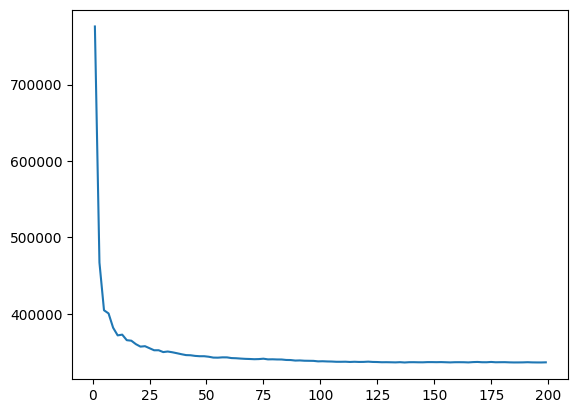

In [64]:
from sklearn.neighbors import KNeighborsRegressor 

u_train, u_test, y_train, y_test = train_test_split(U,y, test_size=.2, random_state=100) #using a 80/20 train/test split because data set is large

def sse(y,y_hat):
    sse = np.sum(((y_test-y_hat)**2))
    return sse

k_grid = [(2*k+1) for k in range(100)]
accuracy = []

for k in k_grid:
    model = KNeighborsRegressor(n_neighbors=k)
    model = model.fit(u_train,y_train)
    y_hat = model.predict(u_test)
    accuracy.append(sse(y_test,y_hat))  

sns.lineplot(x=k_grid, y=accuracy) 
plt.show()

To find the best k, you want to try and minimize the error, or SSE. From the above graph of the SSEs for ks tested from 1 to 200, you should choose a k around 45. After this point, the graph of the SSE does not decrease by much, so the model would not improve much if a higher k were chosen. This is also known as the elbow point in the graph. 

In [95]:
#5. 

model = KNeighborsRegressor(n_neighbors=45)
model = model.fit(u_train,y_train)
y_hat = model.predict(nullrows[["Price", "Beds"]])

<Axes: >

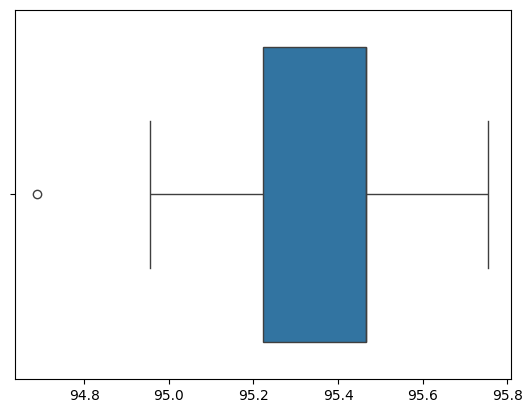

In [96]:
sns.boxplot(x=y_hat)

<Axes: xlabel='Review Scores Rating'>

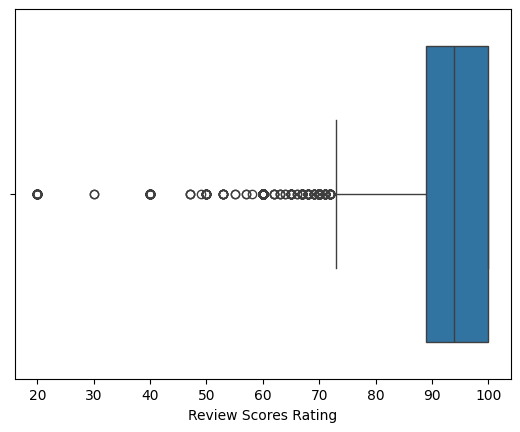

In [99]:
sns.boxplot(x=y_train)

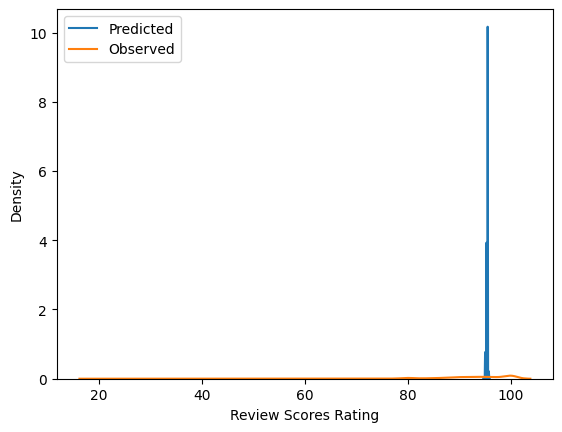

In [103]:
#6. 

sns.kdeplot(x=y_hat, label="Predicted")
sns.kdeplot(x=y_train, label="Observed")
plt.legend()
plt.show()

The predicted missing ratings are all very concentrated around 95. The observed values follow a similar pattern, but there is more overall variability and more lower outliers, making the density lower. This indicates that many of the review score ratings are very similar, which the model reflects in predicting the same values, and price and beds may not be the best predictors to use when making a model.